Dataset size: 80 samples, 1 feature
First 5 samples:
       X      y
0  0.055  0.105
1  0.206  0.351
2  0.344  0.265
3  0.452  0.409
4  0.465  0.282

Kernel       MAE      MSE      R2     Support Vectors
Linear      0.5883   0.4740   -0.1654   57
Polynomial  0.5799   0.4579   -0.1257   56
RBF         0.1125   0.0256   0.9370   37

RBF-SVR: first 5 test predictions
       X  Actual  Predicted
0  3.042   0.020      0.075
1  0.055   0.105      0.142
2  1.987   0.882      0.924
3  3.046   0.172      0.071
4  1.818   0.983      0.984

Prediction for X = 5.0: -0.9809


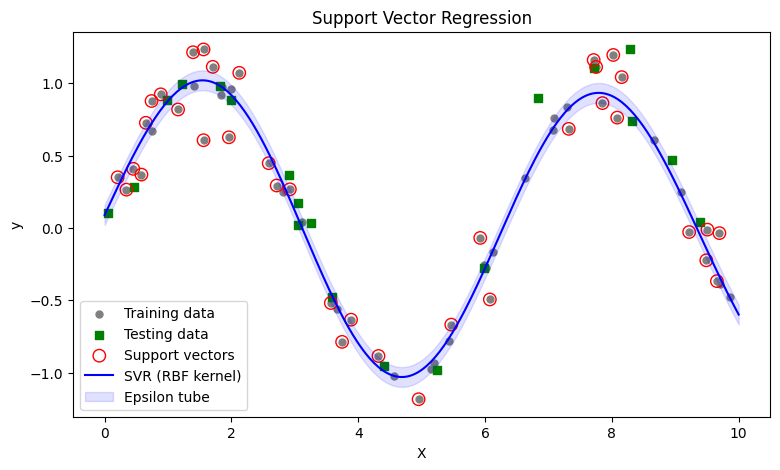

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
X = np.sort(np.random.uniform(0, 10, 80)).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.15, 80)
print("Dataset size:", X.shape[0], "samples, 1 feature")
print("First 5 samples:")
print(pd.DataFrame({'X': X[:5, 0].round(3), 'y': y[:5].round(3)}))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

sc_X = StandardScaler()
sc_y = StandardScaler()
X_train_s = sc_X.fit_transform(X_train)
X_test_s = sc_X.transform(X_test)
y_train_s = sc_y.fit_transform(y_train.reshape(-1, 1)).ravel()

models = {
    'Linear': SVR(kernel='linear', C=1.0, epsilon=0.1),
    'Polynomial': SVR(kernel='poly', degree=3, C=1.0, epsilon=0.1),
    'RBF': SVR(kernel='rbf', C=10.0, gamma='scale', epsilon=0.1)
}

print("\nKernel       MAE      MSE      R2     Support Vectors")
for name, m in models.items():
    m.fit(X_train_s, y_train_s)
    pred = sc_y.inverse_transform(
        m.predict(X_test_s).reshape(-1, 1)).ravel()
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"{name:<11} {mae:.4f}   {mse:.4f}   {r2:.4f}   "
          f"{len(m.support_)}")

rbf = models['RBF']
pred_rbf = sc_y.inverse_transform(
    rbf.predict(X_test_s).reshape(-1, 1)).ravel()
print("\nRBF-SVR: first 5 test predictions")
print(pd.DataFrame({'X': X_test[:5, 0].round(3),
                    'Actual': y_test[:5].round(3),
                    'Predicted': pred_rbf[:5].round(3)}))

new_x = sc_X.transform([[5.0]])
new_y = sc_y.inverse_transform(rbf.predict(new_x).reshape(-1, 1))
print("\nPrediction for X = 5.0:", round(new_y[0, 0], 4))

X_plot = np.linspace(0, 10, 300).reshape(-1, 1)
y_plot = sc_y.inverse_transform(
    rbf.predict(sc_X.transform(X_plot)).reshape(-1, 1)).ravel()
eps_real = 0.1 * sc_y.scale_[0]

plt.figure(figsize=(9, 5))
plt.scatter(X_train, y_train, color='gray', s=25, label='Training data')
plt.scatter(X_test, y_test, color='green', marker='s', s=30,
            label='Testing data')
sv = sc_X.inverse_transform(X_train_s[rbf.support_])
plt.scatter(sv, y_train[rbf.support_], facecolors='none',
            edgecolors='red', s=80, label='Support vectors')
plt.plot(X_plot, y_plot, color='blue', label='SVR (RBF kernel)')
plt.fill_between(X_plot.ravel(), y_plot - eps_real, y_plot + eps_real,
                 color='blue', alpha=0.12, label='Epsilon tube')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Support Vector Regression")
plt.legend()
plt.show()
